<a href="https://colab.research.google.com/github/Daybreak53/HealthEat-Pill-Detection/blob/feat%2Fpill-eda-yang/notebooks/pill_eda_report.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install kagglehub

In [ ]:
import os
from google.colab import userdata # 코랩의 시크릿 모드(Secrets Manager)를 써서 API를 불러옴
import kagglehub

os.environ['KAGGLE_USERNAME'] = userdata.get('KAGGLE_USERNAME') # secret 모드에 KAGGLE_USERNAME 할당
os.environ['KAGGLE_KEY'] = userdata.get('KAGGLE_KEY') # secret 모드에 KAGGLE_KEY 할당

path = kagglehub.competition_download('ai09-level1-project')
print(f'path : {path}')

path : /root/.cache/kagglehub/competitions/ai09-level1-project


경로 설정

In [ ]:
import os
import glob
import pandas as pd

#  기본 경로 설정 (kagglehub에서 리턴해준 path 사용)
base_path = path

# train image, test image, train_annotation 경로 바꾸기
train_img_dir = os.path.join(base_path, 'sprint_ai_project1_data', 'train_images')
train_anno_dir = os.path.join(base_path, 'sprint_ai_project1_data', 'train_annotations')
test_img_dir = os.path.join(base_path, 'sprint_ai_project1_data', 'test_images')

print(f"Train 이미지 경로: {train_img_dir}")
print(f"Train 어노테이션 경로: {train_anno_dir}")
print(f"Test 이미지 경로: {test_img_dir}")

Train 이미지 경로: /root/.cache/kagglehub/competitions/ai09-level1-project/sprint_ai_project1_data/train_images
Train 어노테이션 경로: /root/.cache/kagglehub/competitions/ai09-level1-project/sprint_ai_project1_data/train_annotations
Test 이미지 경로: /root/.cache/kagglehub/competitions/ai09-level1-project/sprint_ai_project1_data/test_images


dataframe으로 변환

In [ ]:
#  모든 JSON 어노테이션 파일 수집
all_annotations = glob.glob(os.path.join(train_anno_dir, "**/*.json"), recursive=True)

# 이미지와 어노테이션 매칭하여 리스트 만들기
data_rows = []
for anno_path in all_annotations:
    # 파일명 추출 (예: 'K-001.json' -> 'K-001.png')
    file_name = os.path.basename(anno_path).replace('.json', '.png')
    img_path = os.path.join(train_img_dir, file_name)

    # 이미지가 실제로 존재하는 경우에만 리스트에 추가 (데이터 정합성 체크)
    if os.path.exists(img_path):
        data_rows.append({
            'image_path': img_path,
            'anno_path': anno_path,
            'file_name': file_name
        })

# 데이터프레임으로 변환하여 관리
df = pd.DataFrame(data_rows)
print(f"전체 학습 가능 데이터 개수: {len(df)}")

전체 학습 가능 데이터 개수: 763


In [ ]:
print(df['anno_path'][0])

/root/.cache/kagglehub/competitions/ai09-level1-project/sprint_ai_project1_data/train_annotations/K-003351-033880-035206_json/K-035206/K-003351-033880-035206_0_2_0_2_90_000_200.json


In [ ]:
import json
# json 파일 load
with open('/root/.cache/kagglehub/competitions/ai09-level1-project/sprint_ai_project1_data/train_annotations/K-003351-033880-035206_json/K-035206/K-003351-033880-035206_0_2_0_2_90_000_200.json', 'r', encoding='utf-8' ) as f:
  pill_content = json.load(f)

# 예제 json 파일 구조 확인
print(pill_content.keys())
example_images = list(pill_content['images'][0].values())
example_image = example_images[3]
print(example_image) # 파일 이름

dict_keys(['images', 'type', 'annotations', 'categories'])
K-003351-033880-035206_0_2_0_2_90_000_200.png


In [ ]:
pill_content['annotations'] # train annotation 정보 파악

[{'area': 86884,
  'iscrowd': 0,
  'bbox': [502, 848, 428, 203],
  'category_id': 35206,
  'ignore': 0,
  'segmentation': [],
  'id': 958,
  'image_id': 255}]

검증용과 train용으로 분할

In [ ]:
from sklearn.model_selection import train_test_split

# 80%는 학습용(train), 20%는 검증용(val)으로 분리
train_df, val_df = train_test_split(df, test_size=0.2, random_state=42)

print(f"학습용 데이터: {len(train_df)}")
print(f"검증용 데이터: {len(val_df)}")

# 테스트 이미지(정답 없음)는 별도로 리스트업
test_images = glob.glob(os.path.join(test_img_dir, "*.png"))
print(f"테스트용 데이터: {len(test_images)}")

학습용 데이터: 610
검증용 데이터: 153
테스트용 데이터: 842


클래스 간 불균형 파악

In [ ]:
import json
from collections import Counter
import matplotlib.pyplot as plt

all_categories = []

for anno_path in df['anno_path']:
  with open(anno_path, 'r', encoding='utf-8') as f:
    data = json.load(f)

    for anno in data['annotations']:
      categories = anno['category_id']
      all_categories.append(categories)

category_counts = Counter(all_categories)
print(f"수집된 카테고리 총 개수: {len(all_categories)}")
print(f"고유 카테고리 종류: {len(category_counts)}")
print(category_counts)

수집된 카테고리 총 개수: 763
고유 카테고리 종류: 56
Counter({3351: 153, 3483: 45, 35206: 37, 16262: 23, 21325: 22, 16232: 21, 3832: 20, 20238: 20, 36637: 19, 29667: 18, 16548: 18, 38162: 18, 19232: 17, 33880: 16, 41768: 16, 20014: 16, 22074: 16, 13900: 15, 18147: 15, 1900: 15, 32310: 14, 18357: 13, 31863: 12, 27733: 12, 25469: 12, 20877: 12, 25367: 12, 22347: 9, 30308: 9, 28763: 9, 2483: 9, 16688: 8, 3544: 6, 29345: 6, 19607: 6, 12778: 6, 25438: 6, 19861: 6, 4543: 5, 12247: 3, 33208: 3, 16551: 3, 24850: 3, 31885: 3, 27926: 3, 21771: 3, 33009: 3, 12081: 3, 34597: 3, 19552: 3, 22362: 3, 29451: 3, 27777: 3, 27993: 3, 13395: 3, 3743: 3})


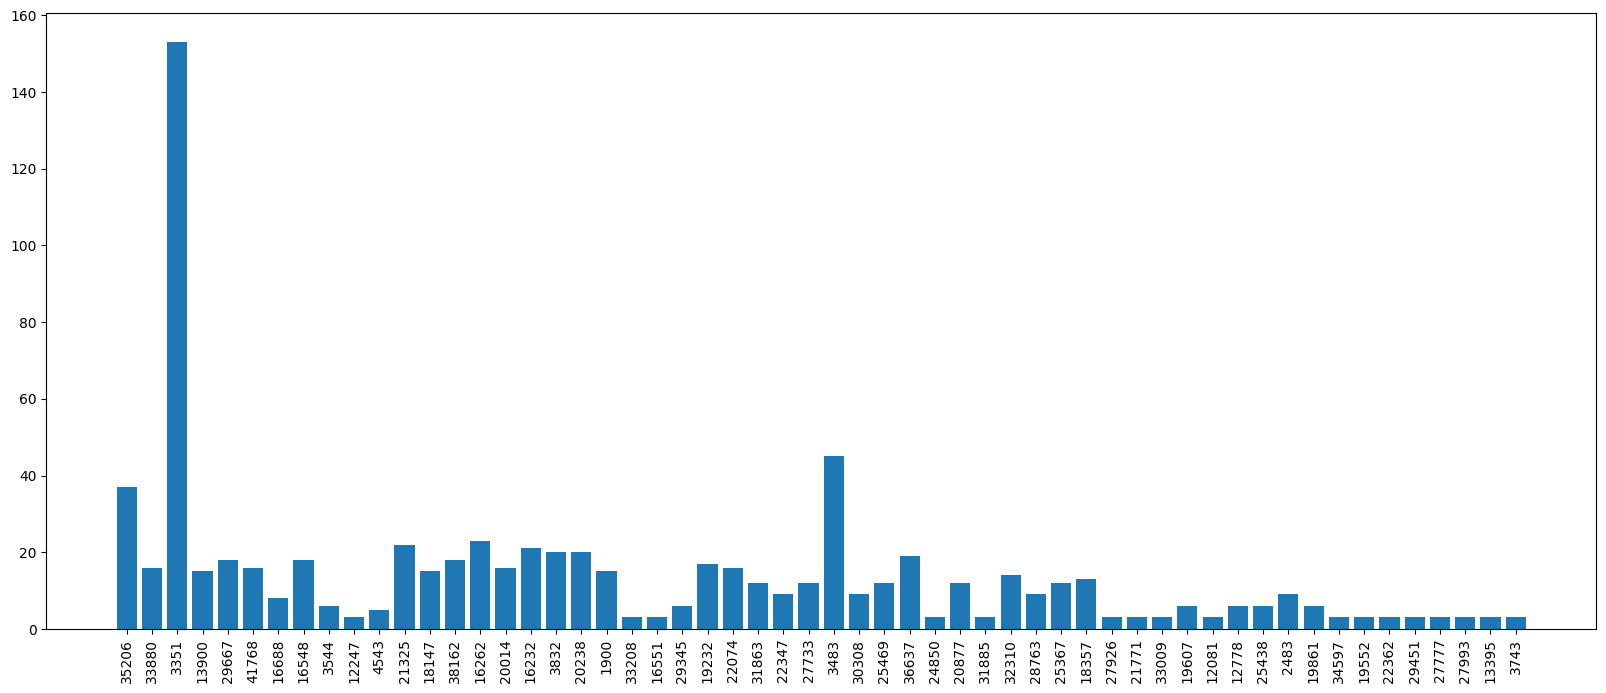

In [ ]:
labels = list(map(str, category_counts.keys())) # 숫자를 문자열로 변환 (가독성)
values = list(category_counts.values())

plt.figure(figsize=(20, 8))
plt.bar(labels, values)
plt.xticks(rotation=90)
plt.show()

 BBox 크기 및 비율 분석

Text(0.5, 1.0, 'aspect ratio')

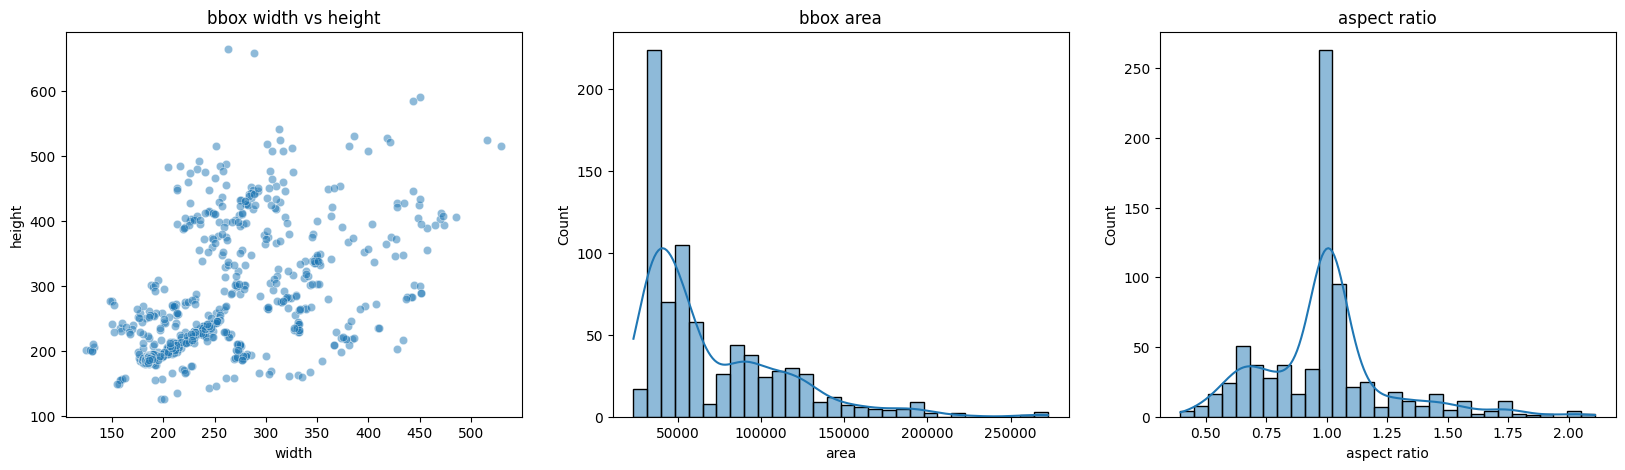

In [ ]:
all_bbox= []

for anno_path in df['anno_path']:
  with open(anno_path, 'r', encoding='utf-8') as f:
    data = json.load(f)

    for anno in data['annotations']:
      bbox = anno['bbox']
      w = bbox[2]
      h = bbox[3]
      all_bbox.append(
          {'width' : w,
           'height' : h,
           'area' : w * h,
           'aspect ratio' : w/h}
      )

bbox_df = pd.DataFrame(all_bbox)

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(20,5))

# width, height의 산점도
plt.subplot(1,3,1)
sns.scatterplot(data=bbox_df, x = 'width', y = 'height', alpha = 0.5)
plt.title('bbox width vs height')

# 면적
plt.subplot(1,3,2)
sns.histplot(data=bbox_df['area'], kde=True, bins=30)
plt.title('bbox area')

# 가로 세로 비율
plt.subplot(1,3,3)
sns.histplot(data=bbox_df['aspect ratio'], kde=True, bins=30)
plt.title('aspect ratio')

transform 설정

In [ ]:
!pip install albumentations

ERROR: Could not find a version that satisfies the requirement albumentations.pytorch (from versions: none)
ERROR: No matching distribution found for albumentations.pytorch


In [ ]:
# 라이브러리 설치
import albumentations as A
from albumentations.pytorch import ToTensorV2

# Train용: 강력한 증강 (데이터 뻥튀기)
train_transform = A.Compose([
    A.Resize(640, 640), # 이미지 크기 통일
    A.HorizontalFlip(p=0.5), # 좌우에 따라서 약이 달라지지 않으므로 좌우 반전
    A.VerticalFlip(p=0.5),   # 상하에 따라서 약이 달라지지 않으므로 상하 반전
    A.RandomRotate90(p=0.5), # 촬영 각도를 반영하기 위해서 90도 단위 회전
    A.RandomBrightnessContrast(p=0.2), # 조명 변화 대응
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)), # 표준정규화
    ToTensorV2() # 파이토치 텐서로 변환
], bbox_params=A.BboxParams(format='coco', label_fields=['class_labels']))

# Validation/Test용: 최소한의 변환 (원본 정보 유지)
val_transform = A.Compose([
    A.Resize(640, 640),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2()
], bbox_params=A.BboxParams(format='coco', label_fields=['class_labels']))

In [ ]:
test_transform = A.Compose([
    A.Resize(640, 640),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])

데이터셋

In [ ]:
import cv2
import torch
import json
from torch.utils.data import Dataset

class PillDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df
        self.transform = transform

    def __len__(self):
        # class 바로 안쪽으로 4칸 들여쓰기
        return len(self.df)

    def __getitem__(self, idx):
        # class 바로 안쪽으로 4칸 들여쓰기
        img_path = self.df.iloc[idx]['image_path']
        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB) # BGR > RGB 변환

        anno_path = self.df.iloc[idx]['anno_path']
        with open(anno_path, 'r') as f:
            data = json.load(f)

            bboxes = []
            labels = []

            for anno in data['annotations']:
                bboxes.append(anno['bbox'])
                labels.append(anno['category_id'])

        # if문은 with문과 같은 레벨 혹은 그 이후에 위치해야 합니다.
        if self.transform:
            augmented = self.transform(image=image, bboxes=bboxes, class_labels=labels)
            image = augmented['image']
            bboxes = augmented['bboxes']
            labels = augmented['class_labels']

        # return은 __getitem__ 함수가 끝나는 지점에 위치해야 합니다.
        return image, torch.tensor(bboxes), torch.tensor(labels)

In [ ]:
class PillTestDataset(Dataset):
    def __init__(self, img_paths, transform=None):
        self.img_paths = img_paths
        self.transform = transform

    def __len__(self):
        return len(self.img_paths)

    def __getitem__(self, idx):
        # 1. 이미지 로드 (테스트는 이미지 파일만 있음)
        img_path = self.img_paths[idx]
        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        # 2. Transform 적용 (Resize, Normalize만 포함된 val_transform 사용)
        if self.transform:
            augmented = self.transform(image=image)
            image = augmented['image']

        # 3. 테스트셋은 이미지와 파일명만 리턴 (나중에 결과 제출용)
        file_name = os.path.basename(img_path)
        return image, file_name

In [ ]:
traindataset = PillDataset(train_df, transform=train_transform)
valdataset = PillDataset(val_df, transform=val_transform)
testdataset = PillTestDataset(test_images, transform=test_transform)

데이터로더

In [ ]:
from torch.utils.data import DataLoader

train_dataloader = DataLoader(traindataset, batch_size=8, shuffle=True, num_workers=2, pin_memory=True)
val_dataloader = DataLoader(valdataset, batch_size=8, shuffle=False, num_workers=2, pin_memory=True)
test_dataloader = DataLoader(testdataset, batch_size=8, shuffle=False, num_workers=2, pin_memory=True)